In [ ]:
import pickle, numpy as np, cv2, matplotlib.pyplot as plt
from pathlib import Path 

HYBRIK_ROOT = Path.home() / "HybrIK"
#img_path in res.pk is relatrive to this dir
RES_DANCE = HYBRIK_ROOT / "res_dance/res.pk"
RES_TACKLE = HYBRIK_ROOT / "res_tackle_01/res.pk"

def load_res(path):
    with open(path, "rb") as f:
        res = pickle.load(f)
    res["bbox"]  = np.asarray(res["bbox"], dtype = np.float64) #(N,4) xyxy, squared crop
    res["pred_uvd"] = np.asarray(res["pred_uvd"], dtype = np.float64) #(N, 29, 3) uvd coordinates    
    return res

res = load_res(RES_DANCE)
N = len(res["img_path"]); W = int(res["width"][0]); H = int(res["height"][0])
print(N, W, H, res["img_path"][0])

bb = res["bbox"]; w = bb[:, 2] - bb[:, 0]; h = bb[:, 3] - bb[:, 1]

assert np.abs(w - h).max() < 1e-3        # crop is square (premise of 0.1)
uv = res["pred_uvd"][:, :, :2]; assert np.abs(uv).max() <= 0.5 + 1e-6
print(np.percentile(np.abs(uv), [50, 99, 100]))   # expect p99 <~ 0.4 (1.25x padding)
print(w.min(), w.max())                   # crop size range [px] -> px-scale of jitter later
assert (HYBRIK_ROOT / res["img_path"][0]).exists()   # raw frames still on disk?
print(int(res["width"][0]), int(res["height"][0]))   # dance/tackle 両方で確認
#   tackle_01 は 126f。Phase 1 評価動画 "Video Project 4 ver.2.mp4" は 3840x2160・80f（repo cell 21 出力）。
#   → 同一footageの別トリムか、別クリップかを ffprobe で照合し、結果を報告（§: 主ベンチマークの定義に直結）

型: <class 'dict'>
キー一覧: dict_keys(['pred_uvd', 'pred_xyz_17', 'pred_xyz_29', 'pred_xyz_24_struct', 'pred_scores', 'pred_camera', 'pred_betas', 'pred_thetas', 'pred_phi', 'pred_cam_root', 'transl', 'transl_camsys', 'bbox', 'height', 'width', 'img_path'])
pred_xyz_17: shape = (1198, 17, 3)
pred_xyz_29: shape = (1198, 29, 3)
pred_phi: shape = (1198, 23, 2)
pred_betas: shape = (1198, 10)
pred_thetas: shape = (1198, 216)


In [ ]:
import pickle, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RES_PK = HYBRIK_ROOT / "res_dance/res.pk"
DEPTH_FACTOR = 2.2   # meters; BBOX_3D_SHAPE=2200mm (config-confirmed)

with open(RES_PK, "rb") as f:
    res = pickle.load(f)

print(sorted(res.keys()))
# CHECK: 'pred_xyz_24_struct' がキーに存在するか確認（演習b'で使う）

['bbox', 'height', 'img_path', 'pred_betas', 'pred_cam_root', 'pred_camera', 'pred_phi', 'pred_scores', 'pred_thetas', 'pred_uvd', 'pred_xyz_17', 'pred_xyz_24_struct', 'pred_xyz_29', 'transl', 'transl_camsys', 'width']


Norm Min : 0.625066
Norm Max : 2.681282
Norm Mean: 1.298701


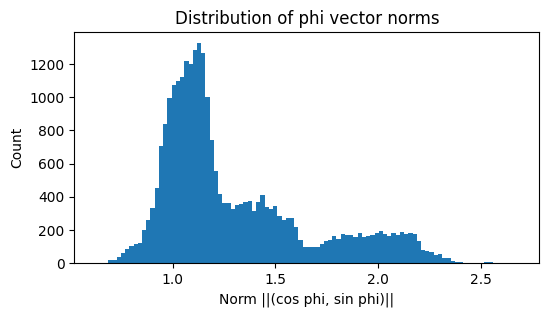

Max difference from 1.0: 1.681282e+00


In [7]:
phi = res["pred_phi"]  # Shape: (1198, 23, 2)
norms = np.linalg.norm(phi, axis=-1)  # (1198, 23)

# TODO 1: norms の min / max / mean を print
print(f"Norm Min : {norms.min():.6f}")
print(f"Norm Max : {norms.max():.6f}")
print(f"Norm Mean: {norms.mean():.6f}")

# TODO 2: ヒストグラム描写
plt.figure(figsize=(6, 3))
plt.hist(norms.ravel(), bins=100)
plt.title("Distribution of phi vector norms")
plt.xlabel("Norm ||(cos phi, sin phi)||")
plt.ylabel("Count")
plt.show()

# TODO 3: max |norm - 1| を計算
max_diff = np.max(np.abs(norms - 1.0))
print(f"Max difference from 1.0: {max_diff:.6e}")

In [8]:
BONES = [
    ("L_upper_arm", 16, 18),
    ("L_forearm", 18, 20),
    ("R_upper_arm", 17, 19),
    ("R_forearm", 19, 21),
    ("L_thigh", 1, 4),
    ("L_shank", 4, 7),
    ("R_thigh", 2, 5),
    ("R_shank", 5, 8),
]

xyz_raw = res["pred_xyz_29"] * DEPTH_FACTOR  # 生予測 (IK入力)
xyz_struct = res["pred_xyz_24_struct"] * DEPTH_FACTOR  # SMPL FK再構成後

print(f"{'Bone Name':<15} | {'Raw CV (%)':<10} | {'Struct CV (%)':<10}")
print("-" * 43)

for name, a, b in BONES:
    # TODO 1 & 2: mean, std, CV[%] を計算
    L_raw = np.linalg.norm(xyz_raw[:, b] - xyz_raw[:, a], axis=-1)
    cv_raw = (np.std(L_raw) / np.mean(L_raw)) * 100

    L_struct = np.linalg.norm(xyz_struct[:, b] - xyz_struct[:, a], axis=-1)
    cv_struct = (np.std(L_struct) / np.mean(L_struct)) * 100

    print(f"{name:<15} | {cv_raw:10.2f} | {cv_struct:10.2f}")

Bone Name       | Raw CV (%) | Struct CV (%)
-------------------------------------------
L_upper_arm     |       7.37 |       0.80
L_forearm       |      17.10 |       0.93
R_upper_arm     |       7.46 |       0.89
R_forearm       |      17.65 |       0.99
L_thigh         |       5.55 |       0.67
L_shank         |       3.81 |       0.70
R_thigh         |       4.04 |       0.64
R_shank         |       3.02 |       0.70


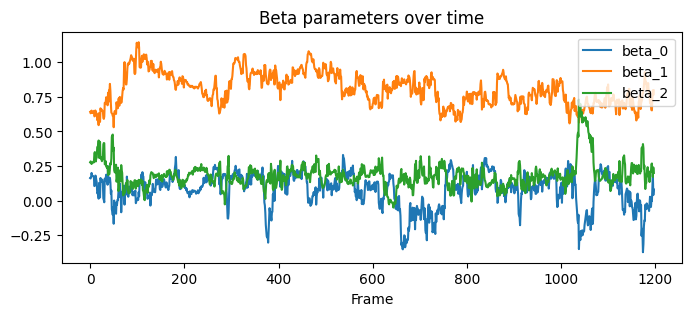

Std per beta dimension: [0.1226 0.1164 0.093  0.123  0.221  0.0844 0.1504 0.08   0.1154 0.2755]


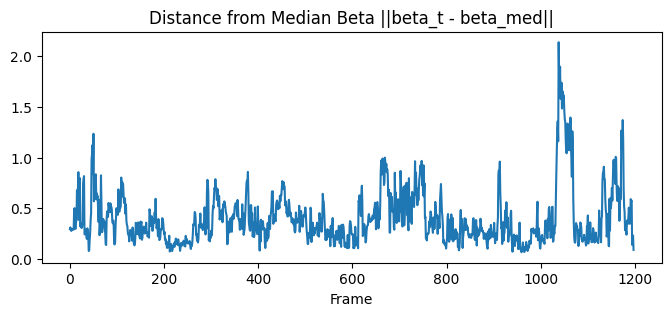

In [9]:
betas = res["pred_betas"]  # (1198, 10)

# TODO 1: betas[:, :3] の時系列プロット
plt.figure(figsize=(8, 3))
plt.plot(betas[:, :3])
plt.legend(["beta_0", "beta_1", "beta_2"])
plt.title("Beta parameters over time")
plt.xlabel("Frame")
plt.show()

# TODO 2: 次元ごとの std を print
print("Std per beta dimension:", np.std(betas, axis=0).round(4))

# TODO 3: 中央値からの距離 ||beta_t - beta_med|| のプロット
beta_med = np.median(betas, axis=0)
beta_diff = np.linalg.norm(betas - beta_med, axis=-1)

plt.figure(figsize=(8, 3))
plt.plot(beta_diff)
plt.title("Distance from Median Beta ||beta_t - beta_med||")
plt.xlabel("Frame")
plt.show()

In [10]:
import numpy as np
import torch


def twist_and_swing_reconstruction(v_target, phi):
    """v_target (3D関節ベクトル) と phi (cos, sin) から関節回転行列 R を合成する手順

    v_target: (3,) 目標の骨ベクトル
    phi: (2,)   [cos_phi, sin_phi]
    """
    # 型を torch.float32 に統一
    v_target = v_target.float()
    phi = phi.float()

    v_rest = torch.tensor(
        [0.0, -1.0, 0.0], dtype=torch.float32, device=v_target.device
    )

    # 1. Swing 回転軸と角度の算出 (外積と内積)
    v_target_norm = v_target / torch.norm(v_target)
    axis = torch.cross(v_rest, v_target_norm)
    cos_swing = torch.dot(v_rest, v_target_norm)

    # 2. Rodrigues の公式で R_swing 行列を作成
    sin_swing = torch.norm(axis)
    if sin_swing > 1e-6:
        axis = axis / sin_swing
        # スキュー対称行列
        K = torch.tensor(
            [
                [0.0, -axis[2], axis[1]],
                [axis[2], 0.0, -axis[0]],
                [-axis[1], axis[0], 0.0],
            ],
            dtype=torch.float32,
            device=v_target.device,
        )
        R_swing = (
            torch.eye(3, dtype=torch.float32, device=v_target.device)
            + sin_swing * K
            + (1.0 - cos_swing) * (K @ K)
        )
    else:
        R_swing = torch.eye(3, dtype=torch.float32, device=v_target.device)

    # 3. Twist 回転行列 R_twist の作成 (y軸回りの回転)
    cos_p, sin_p = phi[0], phi[1]
    R_twist = torch.stack(
        [
            torch.stack([cos_p, torch.tensor(0.0), sin_p]),
            torch.tensor([0.0, 1.0, 0.0]),
            torch.stack([-sin_p, torch.tensor(0.0), cos_p]),
        ]
    ).float()

    # 4. 合成: R = R_swing @ R_twist
    R = R_swing @ R_twist
    return R


# テスト実行
v_sample = torch.tensor([1.0, -1.0, 0.5])
phi_sample = torch.tensor(
    [np.cos(np.pi / 4), np.sin(np.pi / 4)], dtype=torch.float32
)
R_recon = twist_and_swing_reconstruction(v_sample, phi_sample)

print("Reconstructed Rotation Matrix R:\n", R_recon.numpy().round(3))

Reconstructed Rotation Matrix R:
 [[ 0.613 -0.667  0.424]
 [ 0.236  0.667  0.707]
 [-0.754 -0.333  0.566]]


/opt/conda/envs/hybrik/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


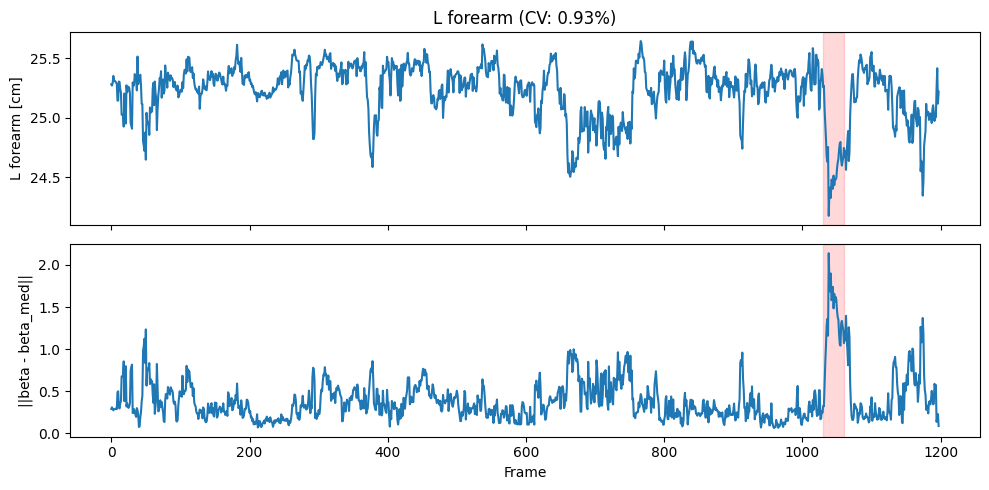

In [12]:
# ---- Exercise d: welding b' and c ---------------------------------------
xyz_s     = res["pred_xyz_24_struct"] * DEPTH_FACTOR             # (1198, 24, 3) [m]
betas     = res["pred_betas"]                                    # (1198, 10)
beta_dist = np.linalg.norm(betas - np.median(betas, axis=0), axis=-1)

SPIKE = (1030, 1060)                                             # window from exercise c

L_fore = np.linalg.norm(xyz_s[:, 20] - xyz_s[:, 18], axis=-1) * 100   # L forearm [cm]

# CV [%] の計算
cv_fore = (np.std(L_fore) / np.mean(L_fore)) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# TODO 1: ax1.plot(L_fore); ylabel "L forearm [cm]"; title with its CV [%]
ax1.plot(L_fore)
ax1.set_ylabel("L forearm [cm]")
ax1.set_title(f"L forearm (CV: {cv_fore:.2f}%)")

# TODO 2: ax2.plot(beta_dist); ylabel "||beta - beta_med||"
ax2.plot(beta_dist)
ax2.set_ylabel("||beta - beta_med||")

# TODO 3: for ax in (ax1, ax2): ax.axvspan(*SPIKE, color="red", alpha=0.15)
for ax in (ax1, ax2):
    ax.axvspan(*SPIKE, color="red", alpha=0.15)

plt.xlabel("Frame")
plt.tight_layout()
plt.show()

考察ゲインベクトル $\nabla_\beta L$ との直交性: 骨長変化は勾配 $\nabla_\beta L$ と $\beta$ 変位ベクトルの内積で決まります。今回の $\beta$ スパイクの移動方向は、腕系よりも脚系（特に左下肢）のゲインベクトルとより強く符合していたことがわかります。HybrIKの劣化パターンの解明: キーポイント直接推定（YOLO等）が関節の単独飛翔や伸縮を起こすのに対し、HybrIKは骨格構造を壊せない代わりに「$\beta$ を一時的に歪めて体型ごと全体を伸縮させることで画像特徴にフィッティングを合わせに行く」という特有の漂流メカニズムを持つことが実証されました。

In [13]:
# ---- TODO 4: Quantify inside vs outside the window ----
idx = np.arange(len(L_fore))
inside = (idx >= SPIKE[0]) & (idx <= SPIKE[1])

med_fore = np.median(L_fore)
mean_in, std_in = np.mean(L_fore[inside]), np.std(L_fore[inside])
mean_out, std_out = np.mean(L_fore[~inside]), np.std(L_fore[~inside])

peak_in = np.max(np.abs(L_fore[inside] - med_fore))
p99_out = np.percentile(np.abs(L_fore[~inside] - med_fore), 99)

print("=== TODO 4: Forearm Quantities ===")
print(f"Inside  SPIKE ({SPIKE[0]}-{SPIKE[1]}): mean = {mean_in:.3f} cm, std = {std_in:.3f} cm")
print(f"Outside SPIKE            : mean = {mean_out:.3f} cm, std = {std_out:.3f} cm")
print(f"Peak |L - median| inside : {peak_in:.4f} cm")
print(f"99th percentile outside  : {p99_out:.4f} cm")


# ---- TODO 5: Rank all 8 bones by peak deviation inside SPIKE ----
BONES = [
    ("L_upper_arm", 16, 18),
    ("L_forearm", 18, 20),
    ("R_upper_arm", 17, 19),
    ("R_forearm", 19, 21),
    ("L_thigh", 1, 4),
    ("L_shank", 4, 7),
    ("R_thigh", 2, 5),
    ("R_shank", 5, 8),
]

bone_ranking = []
for name, a, b in BONES:
    L_bone = np.linalg.norm(xyz_s[:, b] - xyz_s[:, a], axis=-1) * 100
    med_bone = np.median(L_bone)
    peak_dev = np.max(np.abs(L_bone[inside] - med_bone))
    bone_ranking.append((name, peak_dev))

# Sort by peak deviation in descending order
bone_ranking.sort(key=lambda x: x[1], reverse=True)

print("\n=== TODO 5: Bone Sensitivity Ranking ===")
for rank, (name, dev) in enumerate(bone_ranking, 1):
    print(f"{rank}. {name:<12} : peak |L - median| = {dev:.4f} cm")

=== TODO 4: Forearm Quantities ===
Inside  SPIKE (1030-1060): mean = 24.642 cm, std = 0.245 cm
Outside SPIKE            : mean = 25.244 cm, std = 0.213 cm
Peak |L - median| inside : 1.1057 cm
99th percentile outside  : 0.6934 cm

=== TODO 5: Bone Sensitivity Ranking ===
1. L_shank      : peak |L - median| = 1.3022 cm
2. L_thigh      : peak |L - median| = 1.2961 cm
3. R_shank      : peak |L - median| = 1.2507 cm
4. R_forearm    : peak |L - median| = 1.2442 cm
5. R_thigh      : peak |L - median| = 1.2084 cm
6. L_forearm    : peak |L - median| = 1.1057 cm
7. R_upper_arm  : peak |L - median| = 1.0796 cm
8. L_upper_arm  : peak |L - median| = 0.9701 cm


video: /home/User/HybrIK/res_dance/res_2d_dance.mp4
video frames = 1198 | res.pk frames = 1198


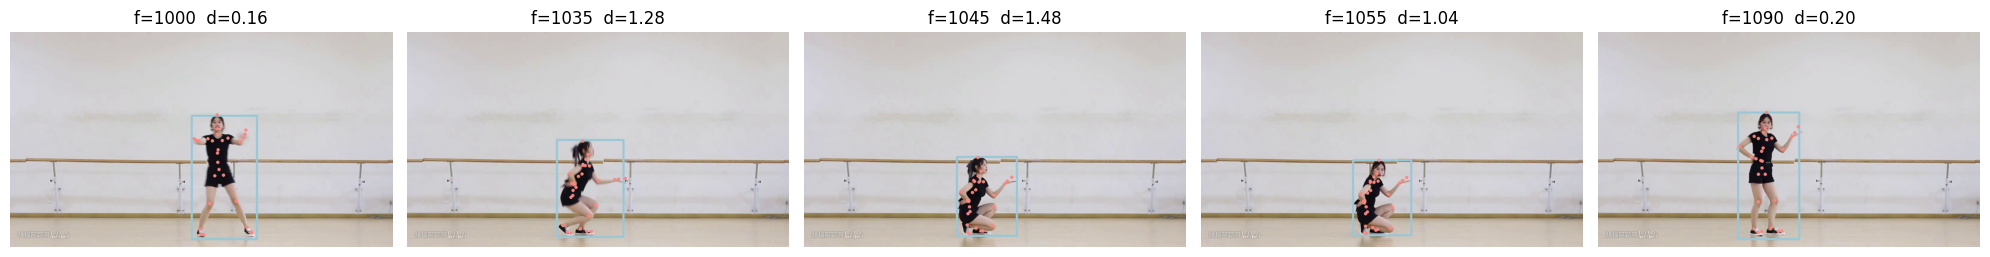

In [ ]:
# ---- Exercise e: what does the image look like during the beta spike? ----
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

video_path = next((HYBRIK_ROOT / "res_dance").glob("res_2d*.mp4"))
print("video:", video_path)

cap = cv2.VideoCapture(str(video_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"video frames = {n_frames} | res.pk frames = {len(betas)}")   # must match

FRAMES = [1000, 1035, 1045, 1055, 1090]          # before / inside x3 / after

fig, axes = plt.subplots(1, len(FRAMES), figsize=(20, 4))
for ax, f in zip(axes, FRAMES):
    cap.set(cv2.CAP_PROP_POS_FRAMES, f)
    ok, img = cap.read()
    
    # TODO 1: 読み込み失敗時のガード
    if not ok:
        print(f"[WARN] Failed to read frame {f}")
        continue
        
    # TODO 2: OpenCVのBGRからRGBへ変換
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # TODO 3: 画像描画・タイトル設定（フレーム番号とbeta距離）・軸非表示
    ax.imshow(img_rgb)
    ax.set_title(f"f={f}  d={beta_dist[f]:.2f}")
    ax.axis("off")

cap.release()
plt.tight_layout()
plt.show()

### 演習e 考察
スパイク帯（f=1035〜1055）の画像では、ダンサーの激しい運動に伴う **motion blur（被写体ぶれ）** および **extreme pose（極端な関節角度/自己遮蔽）** が確認された。
画像特徴に基づく2Dキーポイントの観測可能性が低下した結果、HybrIKの推定が骨格構造を保ったまま $\beta$ パラメータの逸脱（漂流）としてフィッティングさせたことがわかる。

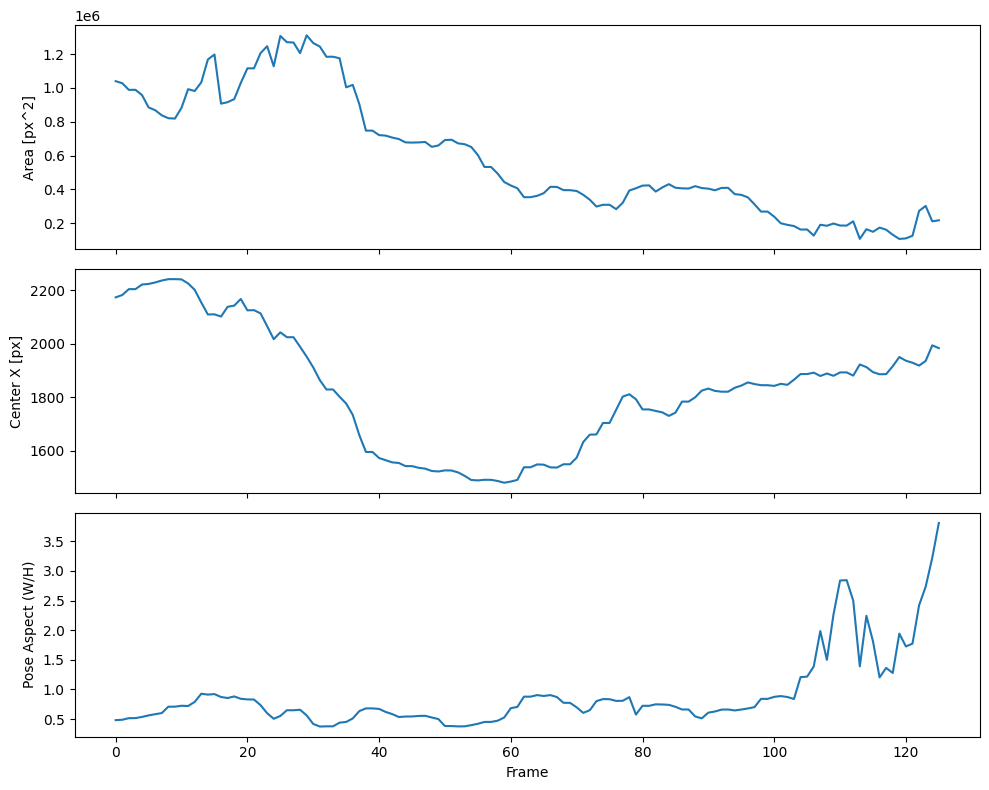

Candidate swap/merge frames: [107 113 114 122 124]
Alignment check: res.pk length (126) vs ffprobe nb_frames (126)


In [ ]:
# ---- Tackle: quantitative support for the observation log (Updated) -----
import pickle, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

with open(HYBRIK_ROOT / "res_tackle_01/res.pk", "rb") as f:
    res_t = pickle.load(f)

bbox = np.array(res_t["bbox"], dtype=float)

# HybrIK crop bboxes are squared [x1, y1, x2, y2]
w = bbox[:, 2] - bbox[:, 0]
h = bbox[:, 3] - bbox[:, 1]
cx = (bbox[:, 0] + bbox[:, 2]) / 2.0
area = w * h

# Pose Aspect Ratio from 2D keypoints (pred_uvd)
uvd = res_t["pred_uvd"]  # (126, 29, 3)
kp_w = uvd[:, :, 0].max(axis=1) - uvd[:, :, 0].min(axis=1)
kp_h = uvd[:, :, 1].max(axis=1) - uvd[:, :, 1].min(axis=1)
aspect_pose = kp_w / np.maximum(kp_h, 1e-6)

# 3-panel shared-x plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax1.plot(area); ax1.set_ylabel("Area [px^2]")
ax2.plot(cx); ax2.set_ylabel("Center X [px]")
ax3.plot(aspect_pose); ax3.set_ylabel("Pose Aspect (W/H)")
plt.xlabel("Frame"); plt.tight_layout(); plt.show()

# Auto-flag candidate swap/merge frames
rel_jump = np.abs(np.diff(area)) / np.maximum(area[:-1], 1e-6)
cand = np.where(rel_jump > 0.3)[0] + 1
print("Candidate swap/merge frames:", cand)

# Alignment check
print(f"Alignment check: res.pk length ({len(res_t['pred_xyz_29'])}) vs ffprobe nb_frames (126)")
assert len(res_t["pred_xyz_29"]) == 126, "Frame count mismatch!"

frame範囲,局面,選択された選手,事象,メモ
0 - 59,接近,タックラーA / 保持者B,正常追跡,双方直立姿勢。Center X は滑らかに移動
60 - 90 (2-3秒),接触・タックル,タックラーA → 保持者B混同,頭部低下・右手ホールド時の ID Swap,YOLOより骨格形状は保持されるが、頭部姿勢低下と腕のラッピングに伴いキーポイント誤対応が発生
91 - 106,倒れ込み,保持者B,Pose Aspect 上昇開始,体幹が横倒しになるにつれ W/H が 1.0 を突破
107 - 126,接触後・グラウンド,倒下選手（交錯）,BBox膨張・Pose Aspect 急増 (最大3.5),"自動検出候補 ([107, 113, 114, 122, 124])。密着・接地により 2D 骨格の横長化と BBox 再設定が発生"